In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
(x_train, _), (_, _) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
x_train = x_train.astype("float32")
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)


In [ ]:
batch_size = 64
noise_dim = 100
epochs = 5


In [ ]:
x_train[0:0]

array([], shape=(0, 28, 28, 1), dtype=float32)

In [ ]:
dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(60000).batch(batch_size)


In [ ]:
dataset

<_BatchDataset element_spec=TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name=None)>

In [ ]:
generator = keras.Sequential([
    keras.layers.Input(shape=(noise_dim,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(28 * 28 * 1, activation='tanh'),
    keras.layers.Reshape((28, 28, 1))])

In [ ]:
discriminator = keras.Sequential([
    keras.layers.Input(shape=(28, 28, 1)),
    keras.layers.Flatten(),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

In [ ]:
loss_fn = keras.losses.BinaryCrossentropy()
g_optimizer = keras.optimizers.Adam(learning_rate=0.0002)
d_optimizer = keras.optimizers.Adam(learning_rate=0.0002)



In [ ]:
for epoch in range(epochs):

    for real_images in dataset:

        # Find current batch size
        batch_size_now = real_images.shape[0]

        # Create labels
        real_labels = tf.ones((batch_size_now,1))
        fake_labels = tf.zeros((batch_size_now,1))


        # -------- Train Discriminator --------

        noise = tf.random.normal((batch_size_now, noise_dim))

        fake_images = generator(noise, training=True)

        with tf.GradientTape() as tape:

            real_output = discriminator(real_images, training=True)

            fake_output = discriminator(fake_images, training=True)

            real_loss = loss_fn(real_labels, real_output)

            fake_loss = loss_fn(fake_labels, fake_output)

            d_loss = real_loss + fake_loss

        d_gradients = tape.gradient(d_loss, discriminator.trainable_variables)

        d_optimizer.apply_gradients(zip(d_gradients, discriminator.trainable_variables))


        # -------- Train Generator --------

        noise = tf.random.normal((batch_size_now, noise_dim))

        with tf.GradientTape() as tape:

            generated_images = generator(noise, training=True)

            output = discriminator(generated_images, training=True)

            g_loss = loss_fn(real_labels, output)

        g_gradients = tape.gradient(g_loss, generator.trainable_variables)

        g_optimizer.apply_gradients(zip(g_gradients, generator.trainable_variables))


    print(f"Epoch [{epoch+1}/{epochs}] D Loss: {d_loss.numpy():.4f} G Loss: {g_loss.numpy():.4f}")

Epoch [1/5] D Loss: 0.2973 G Loss: 1.7925
Epoch [2/5] D Loss: 0.5068 G Loss: 1.5265
Epoch [3/5] D Loss: 0.4668 G Loss: 2.0189
Epoch [4/5] D Loss: 0.6750 G Loss: 1.3824
Epoch [5/5] D Loss: 0.5541 G Loss: 2.0266


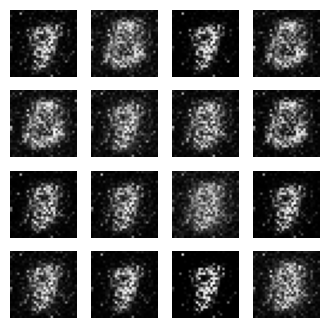

In [ ]:

noise = tf.random.normal((16, noise_dim))

generated_images = generator(noise, training=False)

generated_images = (generated_images + 1) / 2

plt.figure(figsize=(4,4))

for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(generated_images[i,:,:,0], cmap="gray")
    plt.axis("off")

plt.show()